
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_01_pinguinos_v2_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




LABORATORIO — Observatorio de Datos (Pingüinos)

Objetivo
Guiar para la exploración, descripción, formulación de hipótesis y pruebas básicas usando el dataset de pingüinos, hasta generar un reporte reproducible. El laboratorio se divide en dos fases: (1) enfoque clásico con notebook y (2) enfoque con agentes.

Requisitos
- Python 3.x
- pandas, numpy, matplotlib, seaborn (opcional)
- scipy (opcional, para pruebas)

FASE 1 — Enfoque clásico (hasta Parte F)

Nota: el estudiante debe construir su propio runner (script en Python) para ejecutar operaciones y guardar artifacts.

Parte A — Observación inicial
1) ¿Cuántas filas y columnas tiene el dataset?
2) ¿Qué variables son numéricas y cuáles categóricas?
3) ¿Cuántos valores faltantes hay por columna?
4) ¿Existen filas duplicadas?
5) ¿Qué variables tienen baja cardinalidad?

Parte B — Descripción
6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
7) Para cada variable categórica, reporte conteos y porcentajes.
8) Construya tablas cruzadas para pares de variables categóricas relevantes.
9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

Parte C — Visualización
10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.

Parte D — Hipótesis (sin causalidad)
15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
   Ejemplos:
   - `flipper_length_mm` se asocia con `body_mass_g`.
   - `bill_length_mm` difiere por `species`.
   - `species` se asocia con `island`.

Parte E — Pruebas estadísticas
16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado).
17) Reporte estadístico y p-valor.
18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

Parte F — Conclusiones y reporte
19) Redacte conclusiones en tres capas:
    A) Hallazgos descriptivos (con evidencia).
    B) Patrones visuales (con evidencia).
    C) Próximas hipótesis a probar.
20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable `sex`, control por `species`).

Parte G — Ejecución del pipeline (opcional)
21) Ejecute el flujo automático:
    - python pipeline.py
22) Revise el HTML final en artifacts/observatorio.html.


FASE 2 — Enfoque con Agentes (Generalización)

En esta fase se introduce una arquitectura basada en la separación entre Agente y Runner. La idea central es simple: el agente planifica e interpreta, el runner ejecuta y calcula. El agente propone qué operaciones realizar y redacta conclusiones, pero no hace cálculos. El runner ejecuta código en Python, calcula estadísticas, genera gráficos y escribe artifacts (archivos JSON/PNG).

Esta separación mejora la reproducibilidad y reduce errores conceptuales: el agente solo puede usar la evidencia contenida en artifacts. No puede inventar valores ni asumir resultados.

El estudiante debe construir su propio runner y conectarlo con las recomendaciones del agente.

---

Preparación del agente

Primero se crea una carpeta independiente para este enfoque. Allí se copia el archivo de guía del agente (por ejemplo, Promts/hola_agentes.txt) y se adapta si es necesario. En cada interacción debe definirse claramente la fase actual (OBSERVE, DESCRIBE o HYPOTHESIZE_AND_CONCLUDE) y qué artifacts están disponibles.

---

Algoritmo general del enfoque con agentes

Antes de usar el agente, se debe tener claro qué es cada componente:

* Runner: script en Python que calcula, genera gráficos y escribe artifacts.
* Artifacts: archivos JSON o PNG que contienen resultados verificables. Son la única fuente válida de evidencia.
* Agente: propone acciones y redacta hipótesis o conclusiones con base en artifacts.

El proceso comienza preparando el runner. Se crea un archivo runner.py con funciones básicas de observación: perfil del dataset, inferencia de esquema, reporte de faltantes y duplicados. Se agrega la carga del dataset (por ejemplo, seaborn o CSV remoto) y la creación automática de la carpeta artifacts. El runner debe poder ejecutar la fase OBSERVE y generar artifacts/00_raw_profile.json.

Luego se inicia la interacción con el agente. En la fase OBSERVE se le indica que no hay artifacts disponibles. El agente responde con un plan de acciones de observación. El runner ejecuta esas acciones y escribe el artifact correspondiente.

Después se amplía el runner con funciones descriptivas: resúmenes numéricos y categóricos, tablas cruzadas, correlaciones y gráficos exploratorios. Se verifica que pueda generar artifacts/04_descriptive_stats.json y artifacts/05_visual_registry.json.

En la fase DESCRIBE, se informa al agente que ya existe el perfil del dataset. El agente propone análisis descriptivos y gráficos exploratorios. El runner ejecuta y guarda los nuevos artifacts.

En la fase HYPOTHESIZE_AND_CONCLUDE, el agente recibe como contexto los artifacts descriptivos. Con base en ellos formula hipótesis falsables, conclusiones descriptivas y preguntas para el humano. Estas se guardan en artifacts/06_hypotheses_log.json, artifacts/07_conclusions.json y, si aplica, artifacts/09_questions.json.

Opcionalmente, pueden ejecutarse pruebas estadísticas adicionales y registrar los resultados en artifacts/08_tests.json.

---

Interacción con el agente

El flujo es cíclico:

1. Solicitar al agente un plan acorde con la fase actual.
2. Ejecutar las acciones con el runner.
3. Guardar artifacts.
4. Repetir el ciclo en la siguiente fase.

En DESCRIBE, los gráficos deben seleccionarse de forma exploratoria, sin sesgo predefinido. En HYPOTHESIZE_AND_CONCLUDE, todas las afirmaciones deben estar sustentadas en artifacts.

---

Generalización

Una vez completado el flujo con un dataset inicial, se repite el proceso con un dataset distinto. El objetivo es verificar que la arquitectura funciona de forma general y analizar qué partes del prompt necesitan ajustes para adaptarse a otros contextos.

---

Entregables

* Reporte final en HTML.
* Resumen en Markdown.
* Hipótesis y conclusiones documentadas.
* Registro de interacción con el agente (prompts y decisiones).
* Comparación entre el enfoque clásico y el enfoque con agentes.

---

Criterios de evaluación

Se evalúa el rigor descriptivo (sin invención de valores), la coherencia entre gráficos e hipótesis, la claridad de las conclusiones, la reproducibilidad del flujo y la calidad de la interacción con el agente. También se considera la capacidad de generalizar el sistema a nuevos datasets.

Este enfoque no busca automatizar el pensamiento, sino estructurarlo: observar, describir e interpretar con evidencia verificable.


Parte 1 del trabajo


In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

In [2]:
df = sns.load_dataset('penguins')
df.head()   
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [3]:
#1 ¿Cuántas filas y columnas tiene el dataset?

"""
Ejecutando el siguiente código se obtiene el número de filas y columnas del dataset,
podemos ver que tiene 344 filas y 7 columnas.
"""
#2 ¿Qué variables son numéricas y cuáles categóricas?
""" 
Se puede ver que con el método info() nos dice cuales variables son numéricas y cuales categóricas, 
en este caso las variables numéricas son:
bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g
y las variables categóricas son: species, island, sex
"""


df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [4]:
#3 ¿Cuántos valores faltantes hay por columna?
"""
Ejecutando el siguiente código se obtiene el número de valores faltantes por columna"""
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [5]:
#4 ¿Existen filas duplicadas?
"""
Podemos ver, ejecutando el siguiente código, que no existen filas duplicadas en el dataset,
 ya que el resultado es 0."""
df.duplicated().sum()

np.int64(0)

In [6]:
#5 ¿Qué variables tienen baja cardinalidad?

card = df.nunique()
baja_card = card[card < 10]

print("la cerdinalidad de cada variable es:")
print(card)
print("Variables con baja cardinalidad:")
print(baja_card)

la cerdinalidad de cada variable es:
species                3
island                 3
bill_length_mm       164
bill_depth_mm         80
flipper_length_mm     55
body_mass_g           94
sex                    2
dtype: int64
Variables con baja cardinalidad:
species    3
island     3
sex        2
dtype: int64


In [7]:
#6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.

columnas_numericas = list(df.columns[df.dtypes == "float64"])

for col in columnas_numericas:
    media = df[col].mean()
    mediana = df[col].median()
    desviacion_estandar = df[col].std()
    rango_intercuartilico = df[col].quantile(0.75) - df[col].quantile(0.25)
    
    print(f"Variable: {col}")
    print(f"Media: {media}")
    print(f"Mediana: {mediana}")
    print(f"Desviación Estándar: {desviacion_estandar}")
    print(f"Rango Intercuartílico: {rango_intercuartilico}")
    print("\n")



Variable: bill_length_mm
Media: 43.9219298245614
Mediana: 44.45
Desviación Estándar: 5.4595837139265315
Rango Intercuartílico: 9.274999999999999


Variable: bill_depth_mm
Media: 17.151169590643278
Mediana: 17.3
Desviación Estándar: 1.9747931568167816
Rango Intercuartílico: 3.0999999999999996


Variable: flipper_length_mm
Media: 200.91520467836258
Mediana: 197.0
Desviación Estándar: 14.061713679356888
Rango Intercuartílico: 23.0


Variable: body_mass_g
Media: 4201.754385964912
Mediana: 4050.0
Desviación Estándar: 801.9545356980956
Rango Intercuartílico: 1200.0




In [8]:
# 7) Para cada variable categórica, reporte la frecuencia de cada categoría.
columnas_categoricas = list(df.columns[df.dtypes == "str"])

for col in columnas_categoricas:
    frecuencias = df[col].value_counts()
    
    print(f"Variable: {col}")
    print("Frecuencia de cada categoría:")
    print(frecuencias)
    print("\n")

Variable: species
Frecuencia de cada categoría:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


Variable: island
Frecuencia de cada categoría:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


Variable: sex
Frecuencia de cada categoría:
sex
Male      168
Female    165
Name: count, dtype: int64




In [9]:
#8) Construya tablas cruzadas para pares de variables categóricas relevantes.

"""
Aunque de esta manera genero las tablas cruzadas de manera automatica y evitando que se generen tablas
entre las mismas variables categoricas, se repiten las tablas cruzadas entre las mismas variables categoricas, 
por ejemplo la tabla cruzada entre species e island
"""

for c1 in columnas_categoricas:
    for c2 in columnas_categoricas:
        if c1 != c2:
            tabla_cruzada = pd.crosstab(df[c1], df[c2])
            print(f"Tabla cruzada entre {c1} y {c2}:")
            print(tabla_cruzada)
            print("\n")

Tabla cruzada entre species y island:
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


Tabla cruzada entre species y sex:
sex        Female  Male
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61


Tabla cruzada entre island y species:
species    Adelie  Chinstrap  Gentoo
island                              
Biscoe         44          0     124
Dream          56         68       0
Torgersen      52          0       0


Tabla cruzada entre island y sex:
sex        Female  Male
island                 
Biscoe         80    83
Dream          61    62
Torgersen      24    23


Tabla cruzada entre sex y species:
species  Adelie  Chinstrap  Gentoo
sex                               
Female       73         34      58
Male         73         34      61


Tabla cruzada entre sex y island:
island  Biscoe  Dream  Torgerse

In [10]:
#9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

correlacion_pearson = df[columnas_numericas].corr(method='pearson')
correlacion_spearman = df[columnas_numericas].corr(method='spearman')
print("Matriz de correlación Pearson:") 
print(correlacion_pearson)
print("\nMatriz de correlación Spearman:") 
print(correlacion_spearman)

Matriz de correlación Pearson:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.235053           0.656181   
bill_depth_mm           -0.235053       1.000000          -0.583851   
flipper_length_mm        0.656181      -0.583851           1.000000   
body_mass_g              0.595110      -0.471916           0.871202   

                   body_mass_g  
bill_length_mm        0.595110  
bill_depth_mm        -0.471916  
flipper_length_mm     0.871202  
body_mass_g           1.000000  

Matriz de correlación Spearman:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.221749           0.672772   
bill_depth_mm           -0.221749       1.000000          -0.523267   
flipper_length_mm        0.672772      -0.523267           1.000000   
body_mass_g              0.583800      -0.432372           0.839974   

                   body_mass_g  
bill_length_mm        0.58

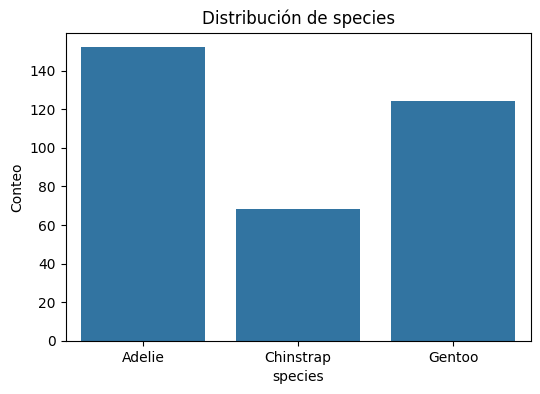

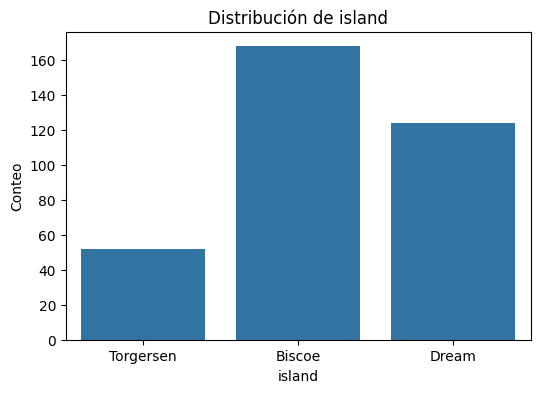

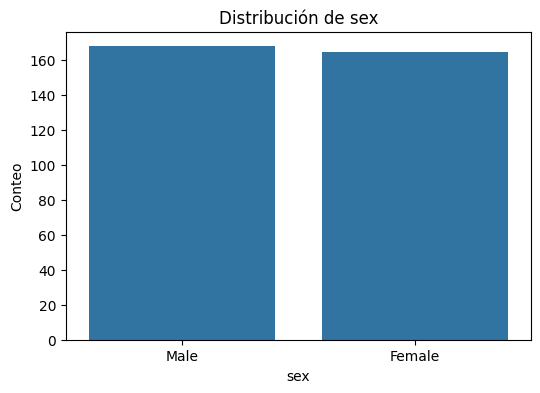

In [11]:
# 10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
for col in columnas_categoricas:
    
    if df[col].nunique() < 10:
        
        plt.figure(figsize=(6,4))
        sns.countplot(data=df, x=col)
        
        plt.title(f"Distribución de {col}")
        plt.xlabel(col)
        plt.ylabel("Conteo")
        
        plt.show()

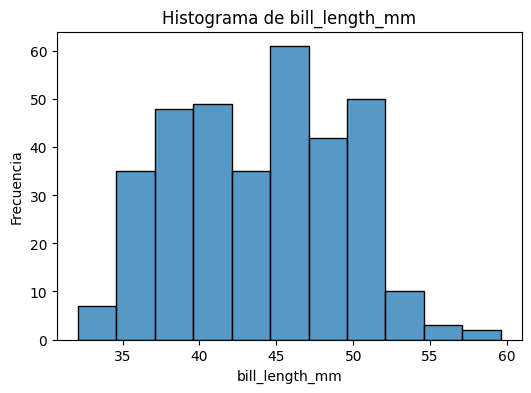

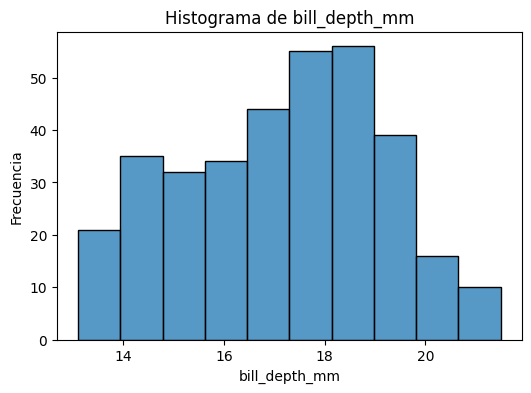

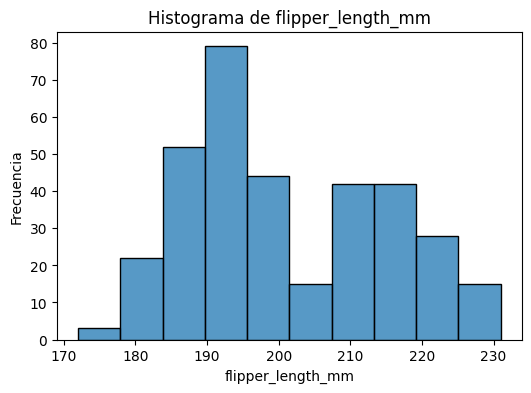

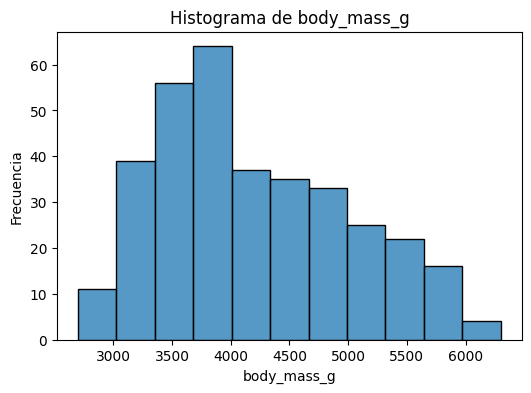

In [12]:
# 11) Genere histogramas para variables numéricas y describa su forma.

for col in columnas_numericas:
    
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col)
    
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    
    plt.show()

bill_length_mm

La distribución es aproximadamente normal, con una ligera asimetría hacia la derecha

bill_depth_mm

Muestra una distribución ligeramente asimétrica 

flipper_length_mm

Es relativamente simétrica

body_mass_g

La variable presenta una distribución aproximadamente normal

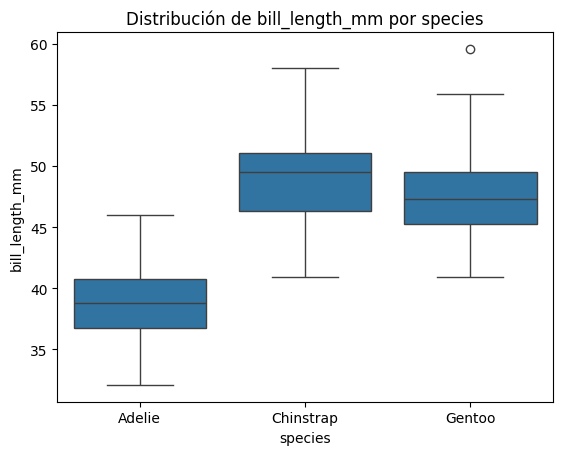

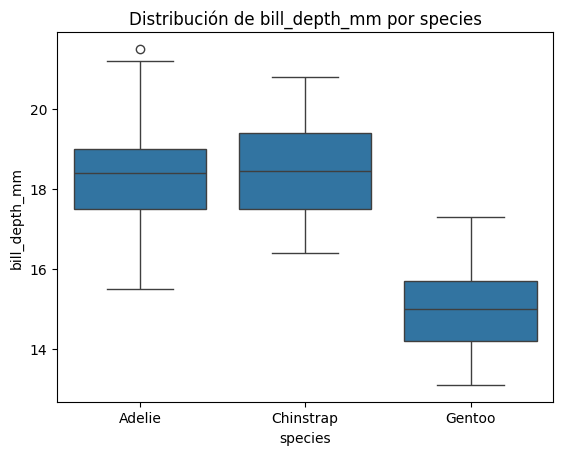

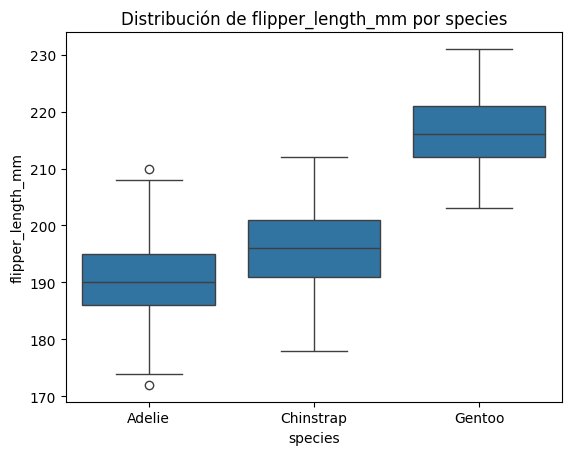

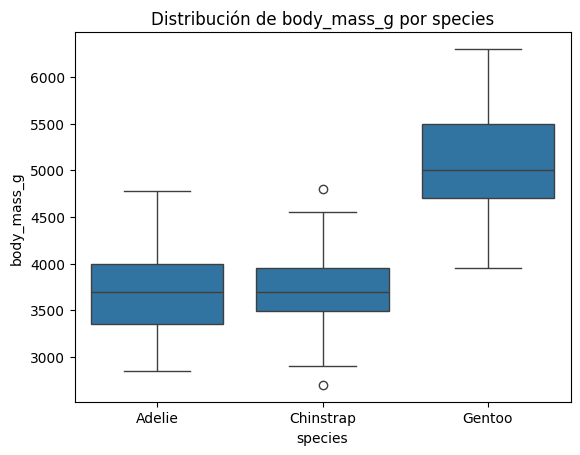

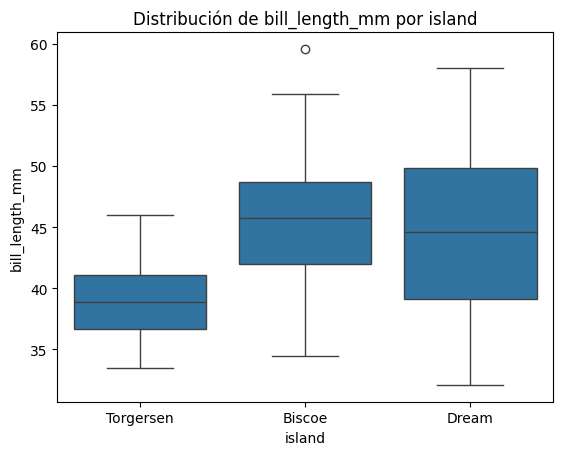

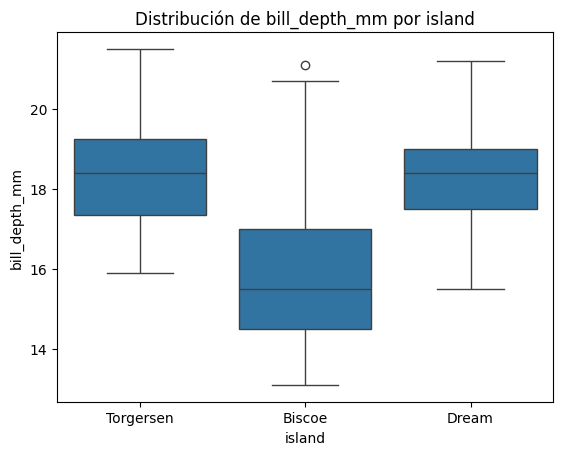

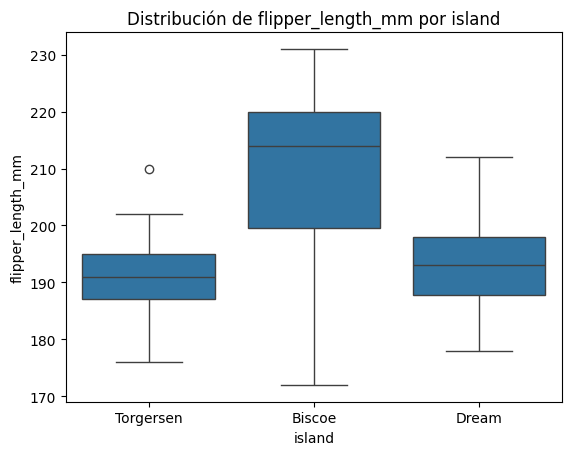

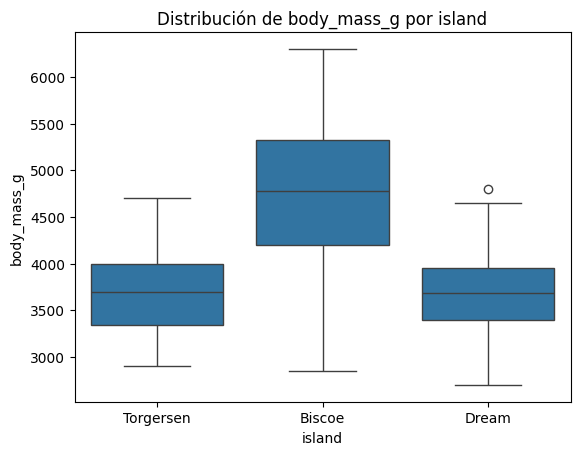

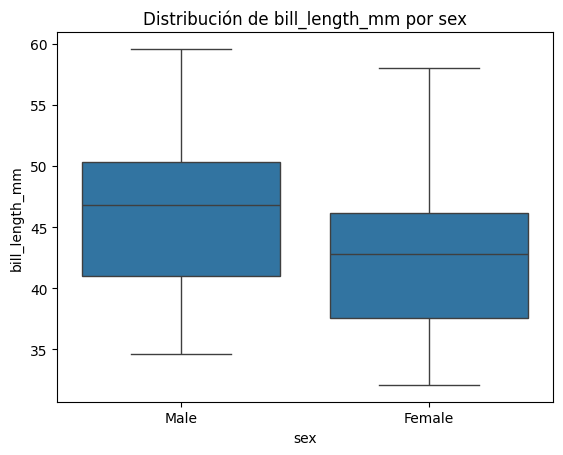

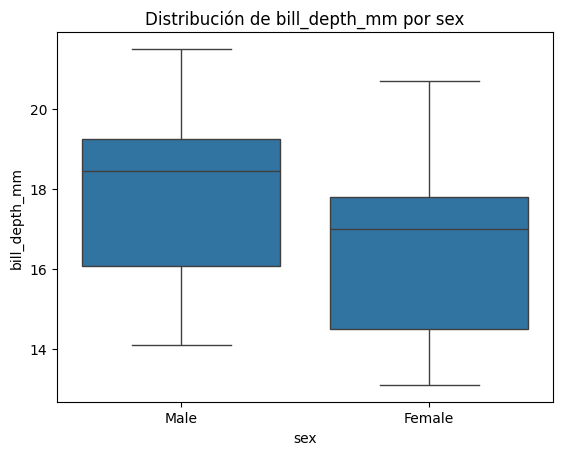

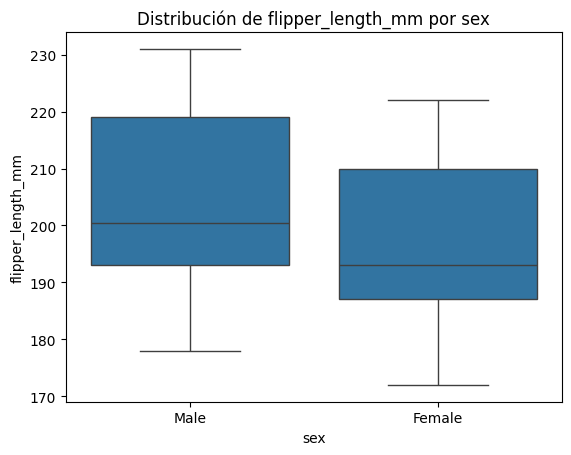

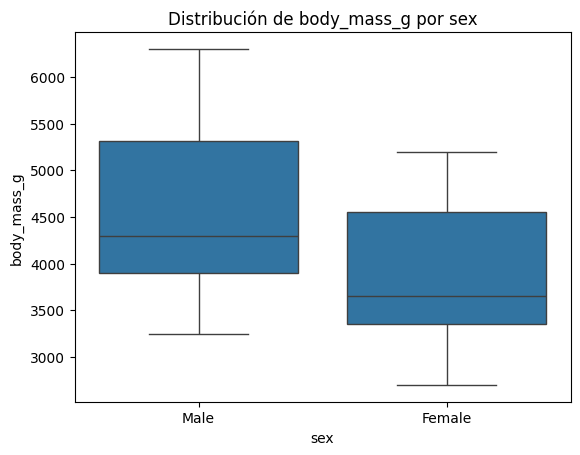

In [13]:
# 12) Genere boxplots de una variable numérica por categoría (p. ej., bill_length_mm por species)

for cat in columnas_categoricas:
    for num in columnas_numericas:
        sns.boxplot(data=df, x=cat, y=num)
        plt.title(f"Distribución de {num} por {cat}")
        plt.show()

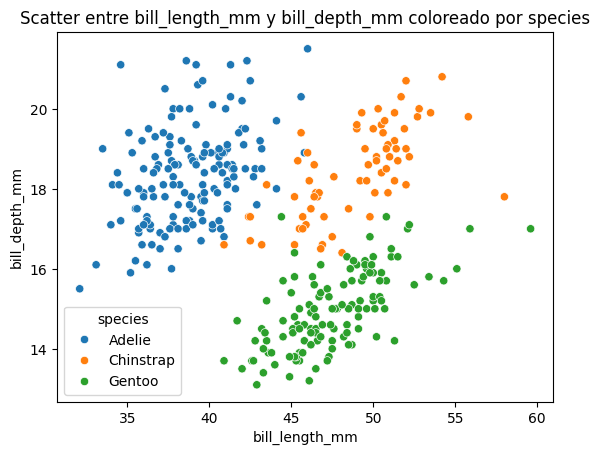

In [14]:
# 13) Genere un scatter entre dos variables numéricas y coloree por una categoría.

sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title("Scatter entre bill_length_mm y bill_depth_mm coloreado por species")
plt.show()

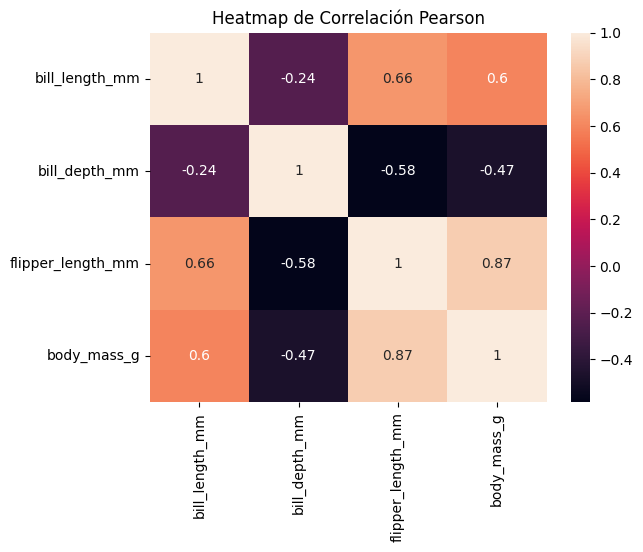

In [15]:
# 14) Genere un heatmap de correlación
sns.heatmap(correlacion_pearson,annot=True)
plt.title("Heatmap de Correlación Pearson")
plt.show()

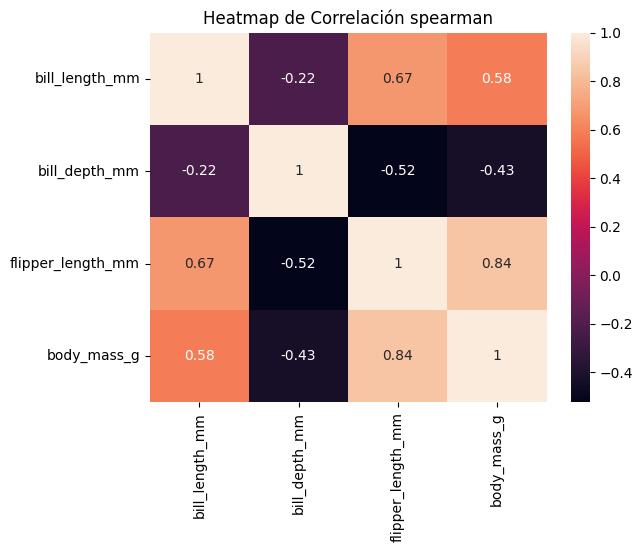

In [16]:
sns.heatmap(correlacion_spearman,annot=True)
plt.title("Heatmap de Correlación spearman")
plt.show()

Parte D — Hipótesis (sin causalidad) 15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos. Ejemplos:

flipper_length_mm se asocia con body_mass_g.
bill_length_mm difiere por species.
species se asocia con island.

Hipótesis 1:
Existe una asociación entre flipper_length_mm y body_mass_g, de modo que pingüinos con aletas más largas tienden a tener mayor masa corporal.

Hipótesis 2:
La variable bill_length_mm difiere entre especies de pingüinos.

Hipótesis 3:
La variable species está asociada con island, lo que sugiere que ciertas especies aparecen con mayor frecuencia en determinadas islas.

In [19]:
#16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado). 
"""
Para la hiptesis 1 se hará una prueba de correlación de perarson entre flipper_length_mm y body_mass_g,
ya que ambas variables son numéricas y se quiere evaluar la relación lineal entre ellas.

Para la hipotesis 2 se hará una prueba de ANOVA entre bill_length_mm y species, ya que se quiere evaluar 
si hay diferencias significativas en bill_length_mm entre las diferentes especies de pingüinos.

Para la hipotesis 3 se hará una prueba de chi-cuadrado entre species e island, ya que ambas variables son categóricas
 y se quiere evaluar si hay una asociación entre la especie de los pingüinos y la isla en la que se encuentran.
"""
#17) Reporte estadístico y p-valor.

#Hipotesis 1
df_clean = df.dropna(subset=["flipper_length_mm", "body_mass_g"])

x = df_clean["flipper_length_mm"].values
y = df_clean["body_mass_g"].values

# estadístico de Pearson
r = np.corrcoef(x, y)[0,1]

print("Coeficiente de correlación (r):", r)

#Hipotesis 2
grupos = df.groupby("species")["bill_length_mm"].apply(lambda x: x.dropna().values)

k = len(grupos)
n_total = sum(len(g) for g in grupos)

media_total = np.mean(np.concatenate(grupos.values))

SS_between = sum(len(g)*(np.mean(g)-media_total)**2 for g in grupos)
SS_within = sum(np.sum((g-np.mean(g))**2) for g in grupos)

df_between = k - 1
df_within = n_total - k

MS_between = SS_between / df_between
MS_within = SS_within / df_within

F = MS_between / MS_within

print("F =", F)

#Hipotesis 3
tabla = pd.crosstab(df["species"], df["island"])

observado = tabla.values

filas = observado.sum(axis=1)
columnas = observado.sum(axis=0)
total = observado.sum()

esperado = np.outer(filas, columnas) / total

chi2 = np.sum((observado - esperado)**2 / esperado)

print("Chi-cuadrado =", chi2)



Coeficiente de correlación (r): 0.8712017673060112
F = 410.6002550405077
Chi-cuadrado = 299.55032743148195


## 18) Evaluación de las hipótesis

### Hipótesis 1  
**Existe una asociación entre `flipper_length_mm` y `body_mass_g`.**

El coeficiente de correlación obtenido fue:

**r = 0.871**

Este valor indica **una asociación positiva fuerte** entre ambas variables. Por lo tanto, **la evidencia apoya la hipótesis de que existe una relación entre la longitud de la aleta y la masa corporal de los pingüinos**.

Es importante destacar que este resultado **indica asociación, pero no implica causalidad**.

---

### Hipótesis 2  
**La variable `bill_length_mm` difiere entre especies de pingüinos.**

El estadístico obtenido en el ANOVA fue:

**F = 410.60**

Este valor sugiere **diferencias sustanciales entre las medias de las especies**, por lo que **la evidencia apoya la hipótesis de que la longitud del pico varía entre especies**.

Sin embargo, este análisis **solo identifica diferencias entre grupos y no establece relaciones causales**.

---

### Hipótesis 3  
**La variable `species` está asociada con `island`.**

El estadístico chi-cuadrado obtenido fue:

**χ² = 299.55**

El valor elevado del estadístico indica **una fuerte discrepancia entre las frecuencias observadas y las esperadas bajo independencia**, lo que sugiere que **la distribución de especies está asociada con la isla**.

Por lo tanto, **la evidencia apoya la hipótesis de asociación entre especie e isla**, sin implicar causalidad.

## Parte F — Conclusiones y reporte

### 19) Conclusiones en tres capas

#### A) Hallazgos descriptivos (con evidencia)

El análisis descriptivo del dataset de pingüinos permitió identificar varias características relevantes.  
Las variables categóricas `species`, `island` y `sex` presentan baja cardinalidad y distribuciones relativamente balanceadas en algunos casos, como ocurre con la variable `sex` dentro de ciertas especies.  

En las variables numéricas se observaron diferencias claras entre especies. Por ejemplo, la variable `bill_length_mm` muestra valores promedio distintos según la especie, lo cual fue confirmado posteriormente mediante un análisis ANOVA (F = 410.60).  

Además, el análisis de correlación indicó una **asociación positiva fuerte entre `flipper_length_mm` y `body_mass_g`** (r = 0.871), lo que sugiere que los pingüinos con aletas más largas tienden a tener mayor masa corporal.

---

#### B) Patrones visuales (con evidencia)

Los gráficos exploratorios permitieron identificar varios patrones en los datos.

Los **histogramas** mostraron que algunas variables numéricas presentan distribuciones que sugieren la presencia de múltiples grupos, lo cual es consistente con la existencia de diferentes especies en el dataset.

Los **boxplots por especie** evidenciaron diferencias claras en variables morfológicas como `bill_length_mm`, donde las medianas y rangos intercuartílicos varían entre especies.

El **scatter plot entre `flipper_length_mm` y `body_mass_g`**, coloreado por especie, mostró una tendencia positiva clara entre ambas variables y evidenció agrupaciones que corresponden a diferentes especies.

Finalmente, el **heatmap de correlación** permitió identificar relaciones fuertes entre algunas variables numéricas, particularmente entre `flipper_length_mm` y `body_mass_g`.

---

#### C) Próximas hipótesis a probar

A partir de los resultados obtenidos, se pueden plantear nuevas hipótesis para análisis futuros:

- La relación entre `flipper_length_mm` y `body_mass_g` podría variar entre especies, por lo que sería interesante analizar esta asociación **controlando por `species`**.
- Las diferencias observadas en `bill_length_mm` podrían explorarse con análisis post-hoc para identificar **qué pares de especies difieren significativamente**.
- Podría investigarse si otras variables morfológicas, como `flipper_length_mm` o `body_mass_g`, también presentan diferencias sistemáticas entre especies.

Estos análisis permitirían comprender con mayor detalle las características morfológicas de las distintas especies de pingüinos.

---

### 20) Preguntas para un investigador humano

Durante el análisis surgieron algunas preguntas que podrían requerir conocimiento del dominio biológico o del proceso de recolección de datos:

- ¿Cómo se manejaron los valores faltantes en la variable `sex` y qué tan confiables son las observaciones disponibles?
- ¿Existen diferencias biológicas conocidas entre especies que expliquen las variaciones observadas en variables morfológicas?
- ¿Las mediciones de masa corporal (`body_mass_g`) fueron tomadas en condiciones comparables entre todas las islas?
- ¿Sería necesario controlar por `species` o `island` al analizar la relación entre variables físicas como `flipper_length_mm` y `body_mass_g`?

Estas preguntas podrían orientar análisis posteriores y ayudar a interpretar los resultados desde una perspectiva biológica más completa.

Estadísticos descriptivos:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000

Frecuencias de species:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Frecuencias de island:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

Frecuencias de sex:
sex
Male      168
Female    165
Name: count, dtype: int64


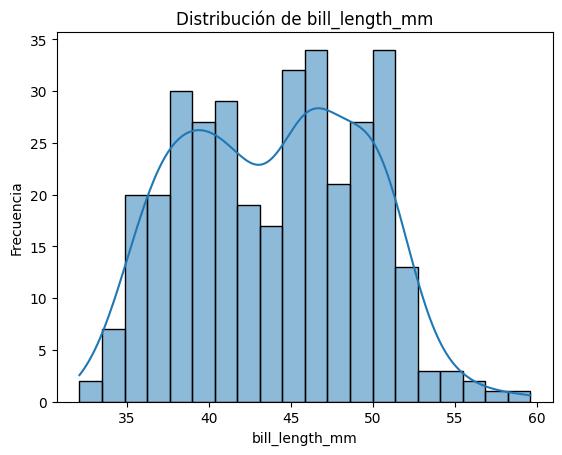

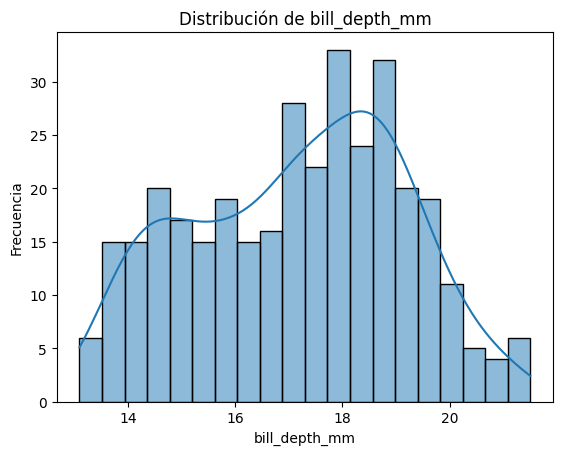

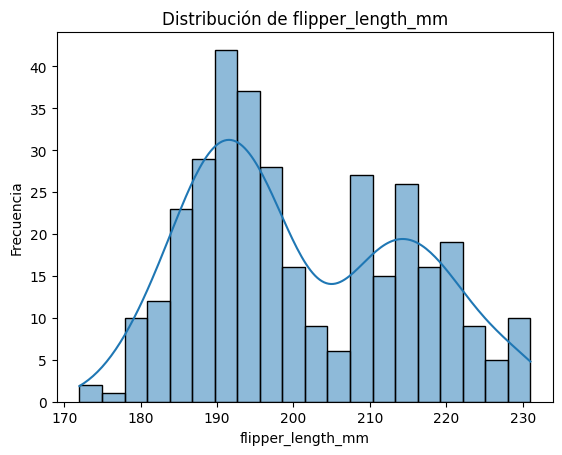

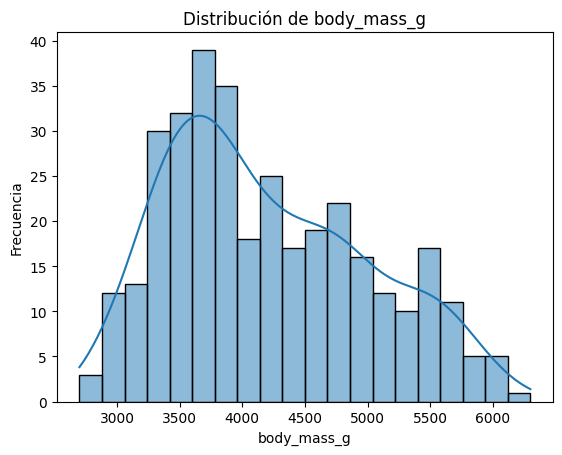

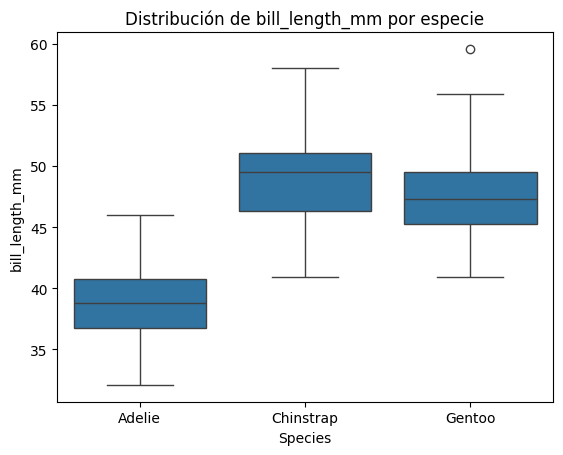

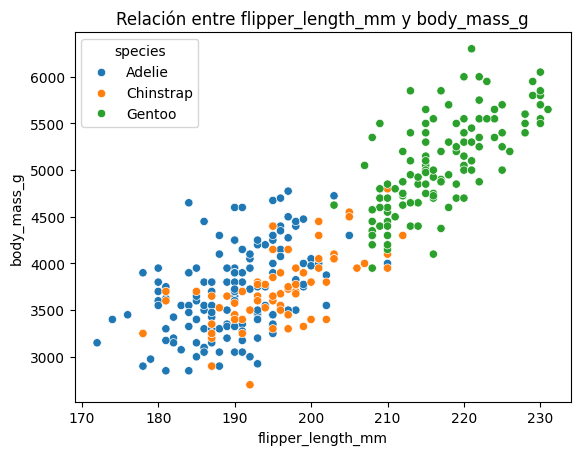

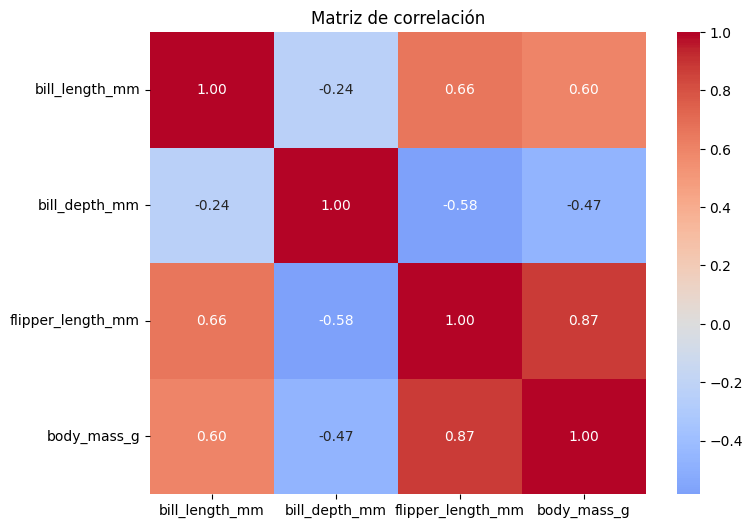

In [ ]:
#Hecho con la ayuda de chatpg (evidencia)

# =========================
# 1) Estadísticos descriptivos
# =========================

print("Estadísticos descriptivos:")
print(df.describe())


# =========================
# 2) Frecuencias de variables categóricas
# =========================

categoricas = ["species", "island", "sex"]

for col in categoricas:
    print(f"\nFrecuencias de {col}:")
    print(df[col].value_counts())


# =========================
# 3) Histogramas (distribuciones)
# =========================

variables_numericas = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

for var in variables_numericas:
    plt.figure()
    sns.histplot(df[var], bins=20, kde=True)
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.show()


# =========================
# 4) Boxplot por especie
# =========================

plt.figure()
sns.boxplot(data=df, x="species", y="bill_length_mm")

plt.title("Distribución de bill_length_mm por especie")
plt.xlabel("Species")
plt.ylabel("bill_length_mm")

plt.show()


# =========================
# 5) Scatter plot (relación entre variables)
# =========================

plt.figure()

sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species"
)

plt.title("Relación entre flipper_length_mm y body_mass_g")
plt.xlabel("flipper_length_mm")
plt.ylabel("body_mass_g")

plt.show()


# =========================
# 6) Heatmap de correlación
# =========================

df_numericas = df.select_dtypes(include="number")
corr = df_numericas.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Matriz de correlación")

plt.show()